# Data Exploration: Alzheimer's MRI Dataset
In this notebook, we visualize sample slices across all four classes to confirm label quality and check class distributions.

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
from pathlib import Path

# Set dataset path
dataset_dir = Path('../dataset/Alzheimer_Dataset_V3/Unaugmented')
classes = sorted([d.name for d in dataset_dir.iterdir() if d.is_dir()])

print("Classes found:", classes)

Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


## Visualizing Samples from Each Class

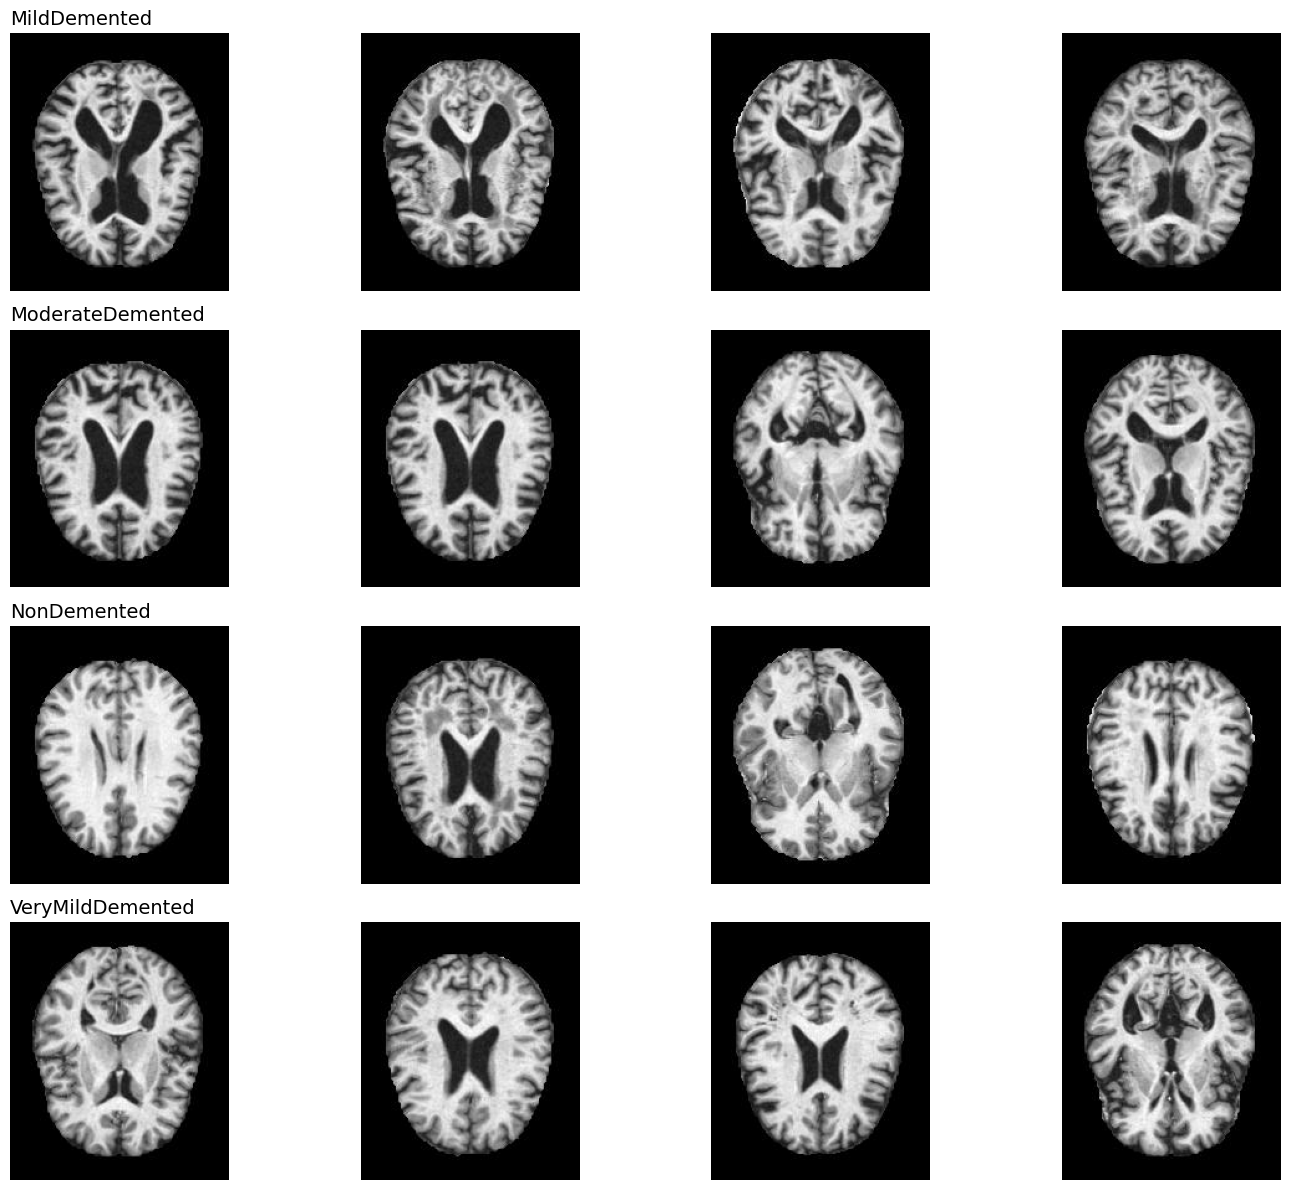

In [2]:
def show_samples(dataset_dir, classes, samples_per_class=4):
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, 12))
    
    for i, cls_name in enumerate(classes):
        cls_dir = dataset_dir / cls_name
        images = list(cls_dir.glob('*.jpg'))
        sampled_images = random.sample(images, min(samples_per_class, len(images)))
        
        for j, img_path in enumerate(sampled_images):
            img = Image.open(img_path)
            ax = axes[i, j]
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(cls_name, fontsize=14, loc='left')
                
    plt.tight_layout()
    plt.show()

show_samples(dataset_dir, classes)

## Class Distribution

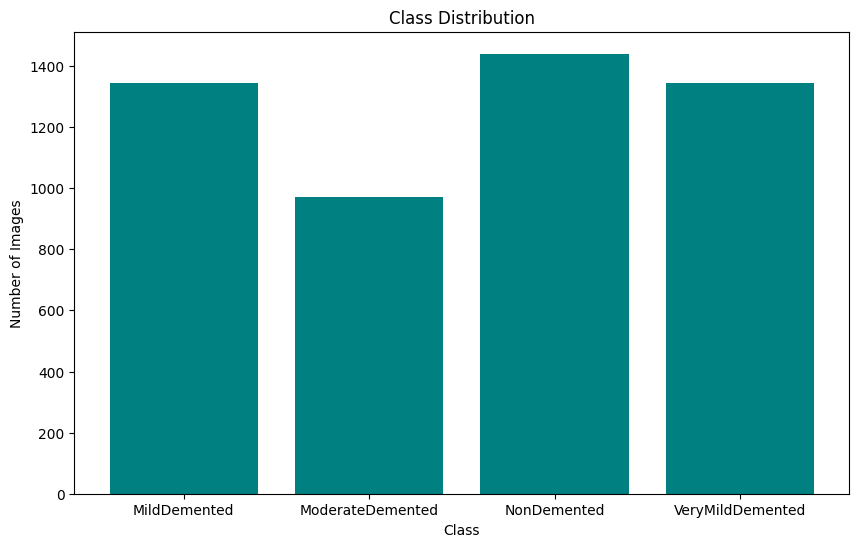

MildDemented: 1344 images
ModerateDemented: 971 images
NonDemented: 1440 images
VeryMildDemented: 1344 images


In [3]:
class_counts = {cls: len(list((dataset_dir / cls).glob('*.jpg'))) for cls in classes}

plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='teal')
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Class')
plt.show()

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")